In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [5]:
import py_deffields as pd

In [6]:
elastic_generator = pd.ElasticDeformation(alpha=4, sigma=8)
deformation_field = elastic_generator.generate((128, 128, 128))

In [10]:
np.any(
    pd.jacobian.jacobian_determinant(deformation_field) < 0
)

np.False_

In [ ]:
print(f'deformation_field shape: {deformation_field.shape}')
norm = np.linalg.norm(deformation_field, axis=0)
print(f'nor')

(128, 128, 128, 3)

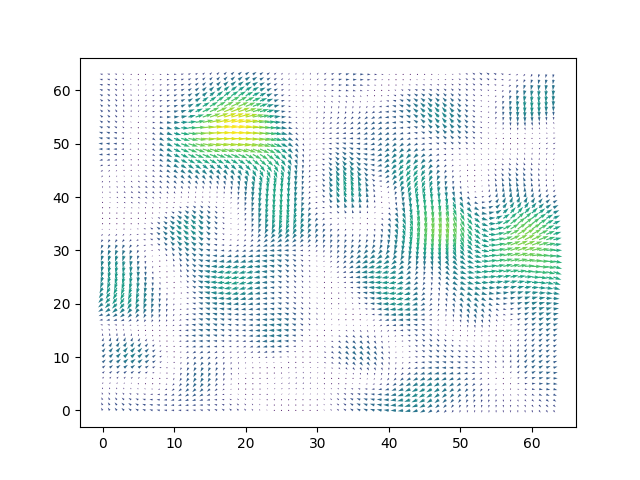

In [7]:
fig, ax = plt.subplots()

subsampling_factor: int = 2

ax.quiver(
    deformation_field[::subsampling_factor, ::subsampling_factor, 64, 0],
    deformation_field[::subsampling_factor, ::subsampling_factor, 64, 1],
    np.linalg.norm(
        deformation_field[::subsampling_factor, ::subsampling_factor, 64, :2],
        axis=-1,
    )
)

In [8]:
import ipywidgets as widgets
import einops

In [26]:
from py_deffields.visualization.quiver import QuiverVisualizer

In [35]:
def _color_map_selection_dropdown() -> widgets.Dropdown:
    choices: list[str] = [
        'none',
        'viridis',
        'plasma',
        'inferno',
        'magma',
        'cividis',
    ]
    return widgets.Dropdown(
        options=choices,
        value='viridis',
        description='Color Map:',
    )

dp = _color_map_selection_dropdown()
dp

Dropdown(description='Color Map:', index=1, options=('none', 'viridis', 'plasma', 'inferno', 'magma', 'cividis…

In [44]:
qvv = QuiverVisualizer.create(deformation_field)
qvv.ux

In [38]:
%load_ext line_profiler

In [40]:
def draw():
    qvv._draw_quiver()

In [43]:
%lprun -f qvv._draw_quiver qvv._draw_quiver()

Timer unit: 1e-09 s

Total time: 0.0366353 s

Could not find file <string>
Are you sure you are running this program from the same directory
that you ran the profiler from?
Continuing without the function's contents.

Line #      Hits         Time  Per Hit   % Time  Line Contents
     2                                           
     3         1     402614.0 402614.0      1.1  
     4         1       2610.0   2610.0      0.0  
     5         1     199567.0 199567.0      0.5  
     6         1       3930.0   3930.0      0.0  
     7         1       1010.0   1010.0      0.0  
     8         1   32529507.0 3.25e+07     88.8  
     9         1    2757222.0 2.76e+06      7.5  
    10         1      60619.0  60619.0      0.2  
    11         1     678231.0 678231.0      1.9

In [9]:
df = einops.rearrange(deformation_field, 'x y z d -> z y x d')

In [10]:
import enum

class AxisState(enum.Enum):
    ZYX = 'zyx'
    ZXY = 'zxy'
    YXZ = 'yxz'
    YZX = 'yzx'
    XZY = 'xzy'
    XYZ = 'xyz'


def _make_axis_dropdown():
    return widgets.Dropdown(
        options=[axis_state.value for axis_state in AxisState],
        value=AxisState.ZYX.value,
        description='Axis Order:',
    )


In [11]:
ddw = _make_axis_dropdown()
ddw

Dropdown(description='Axis Order:', options=('zyx', 'zxy', 'yxz', 'yzx', 'xzy', 'xyz'), value='zyx')

In [12]:

def _make_axis_selector() -> widgets.Dropdown:
    axis_selector = widgets.Dropdown(
        options={
            "XY": 2,
            "XZ": 1,
            "YZ": 0,
        },
        value=2,
        description="Axis:",
    )
    return axis_selector

In [13]:
from IPython.display import display
from py_deffields.visualization.quiver import *

In [14]:
generate_einops_pattern(AxisState.ZYX)

'z y x -> z y x'

In [24]:
def get_vectorfield_component_indices(
    axis_state: AxisState,
) -> tuple[int, int]:
    """
    Select the in-plane vectorfield components according to the AxisState.
    """
    axis_to_index = {'z': 0, 'y': 1, 'x': 2}
    return tuple(axis_to_index[axis] for axis in axis_state.value[1:])


get_vectorfield_component_indices(AxisState.ZYX)

(1, 2)

In [18]:
spatial = (25, slice(None, None, 2), slice(None, None, 2))

selection = np.take(
    deformation_field[*spatial],
    np.array([0, 1]),
    axis=-1
)
print(selection.shape)

index = 0

assert np.allclose(
    selection[..., index],
    deformation_field[25, ::2, ::2, index],    
)

(64, 64, 2)


In [19]:
%timeit np.array([0, 1])

401 ns ± 2.56 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [20]:
%timeit np.take(deformation_field[*spatial], np.array([0, 1]), axis=-1)

36.3 μs ± 94.4 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [21]:
%timeit np.take(deformation_field[*spatial], [0, 1], axis=-1)


36.1 μs ± 203 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [25]:
%timeit AxisState('xyz')

329 ns ± 1.03 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
